# 0. Notebook 03 — Conditional VAE
## Generative Models — From Scratch

Build a Conditional Variational Autoencoder on MNIST using three conditioning mechanisms:

1. One-hot concatenation
2. Learnable label embeddings
3. Feature-wise Linear Modulation (FiLM)

All models use MLPs, a two-dimensional latent variable, and manually implemented reparameterization.

The main goal is simple: give the model a real digit such as `7` and generate an image of that digit.

## 1. What We Are Building

Our final interface is:

```python
generate_digit(selected_model, 7)
```

The model samples a latent vector and generates images without requiring an input image.

- The label `y` specifies **which digit** to generate.
- The latent variable `z` can represent **variation within that digit**.

This distinction is an intended modeling behavior, not a guarantee of perfect disentanglement.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
LATENT_DIM = 2
EMBED_DIM = 16
BATCH_SIZE = 128
EPOCHS = 15
LEARNING_RATE = 1e-3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed()
print("Device:", DEVICE)

Device: cuda


## 2. From VAE to Conditional VAE

An ordinary VAE learns:

- Encoder: $q_\phi(z \mid x)$
- Decoder: $p_\theta(x \mid z)$

A CVAE learns:

- Encoder: $q_\phi(z \mid x,y)$
- Decoder: $p_\theta(x \mid z,y)$

Here, $x$ is an image, $y$ is its digit label, and $z$ is a latent vector.

The important difference is that the decoder also receives the requested label, which makes direct controlled generation possible.

## 3. MNIST Dataset

MNIST contains grayscale handwritten digits from `0` to `9`.

We flatten each image from `[1, 28, 28]` to `[784]` inside the model.

The transform maps pixel values from `[0, 1]` to `[-1, 1]`, so the decoder uses `Tanh`.

100%|██████████| 9.91M/9.91M [00:08<00:00, 1.19MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 122kB/s]
100%|██████████| 1.65M/1.65M [00:03<00:00, 517kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 501kB/s]


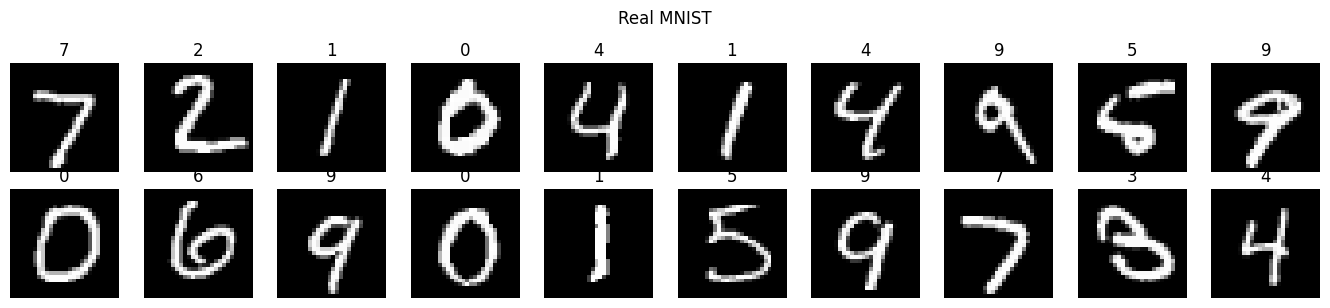

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)


def make_train_loader(seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=0,
    )


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)


def show_images(images, labels=None, title="", ncols=10):
    images = images.detach().cpu().reshape(-1, 28, 28)
    images = ((images + 1) / 2).clamp(0, 1)

    count = len(images)
    if count == 0:
        raise ValueError("No images to display.")

    ncols = min(ncols, count)
    nrows = (count + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(1.35 * ncols, 1.55 * nrows),
        squeeze=False,
    )

    for index, ax in enumerate(axes.flat):
        ax.axis("off")
        if index < count:
            ax.imshow(images[index].numpy(), cmap="gray", vmin=0, vmax=1)
            if labels is not None:
                ax.set_title(str(int(labels[index])))

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


real_x, real_y = next(iter(test_loader))
show_images(real_x[:20], real_y[:20], "Real MNIST")

## 4. Quick VAE Review

The encoder predicts a diagonal Gaussian:

$$q_\phi(z \mid x,y) = \mathcal{N}\left(\mu, \operatorname{diag}(\sigma^2)\right).$$

We sample with the reparameterization trick:

$$z = \mu + \exp(0.5\,\mathrm{logvar}) \odot \epsilon,\qquad \epsilon\sim\mathcal{N}(0,I).$$

Here `logvar` means $\log(\sigma^2)$ and $\odot$ denotes elementwise multiplication.

## 5. Conditional Objective

The conditional ELBO is:

$$
\mathcal{L}_{ELBO}
=
\mathbb{E}_{q_\phi(z\mid x,y)}[\log p_\theta(x\mid z,y)]
-
D_{KL}\left(q_\phi(z\mid x,y)\,\|\,\mathcal{N}(0,I)\right).
$$

In practice we minimize:

$$L = L_{reconstruction} + L_{KL}.$$

Because the images are normalized to `[-1, 1]`, we use summed squared error (MSE-style reconstruction loss) rather than binary cross-entropy.

For the diagonal Gaussian:

$$
L_{KL}
=
-\frac12\sum_j\left(1+\log\sigma_j^2-\mu_j^2-\sigma_j^2\right).
$$

In [3]:
def vae_loss(reconstruction, x, mu, logvar):
    target = x.flatten(start_dim=1)

    reconstruction_per_sample = (
        reconstruction - target
    ).pow(2).sum(dim=1)

    kl_per_sample = -0.5 * (
        1 + logvar - mu.pow(2) - logvar.exp()
    ).sum(dim=1)

    reconstruction_loss = reconstruction_per_sample.mean()
    kl_loss = kl_per_sample.mean()
    total_loss = reconstruction_loss + kl_loss

    return total_loss, reconstruction_loss, kl_loss

## 6. How Can We Represent the Condition?

| Method | Label representation | Injection mechanism |
|---|---|---|
| One-hot | Fixed vector of length 10 | Concatenate with image and latent |
| Embedding | Learned vector of length 16 | Concatenate with image and latent |
| FiLM | Learned embedding | Modulate hidden features |

Passing the scalar `7.0` as an ordinary numerical feature introduces an unnecessary ordinal interpretation.

Passing the integer index `7` to `nn.Embedding`, however, is correct: it selects one row from a learned lookup table.

In [4]:
class BaseCVAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.latent_dim = latent_dim

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        return mu + std * epsilon

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z, y)
        return reconstruction, mu, logvar, z

## 7. Method 1 — One-Hot Concatenation

For a batch size $B$:

- Images: `[B, 784]`
- One-hot labels: `[B, 10]`
- Encoder input: `[B, 794]`
- Latent vectors: `[B, 2]`
- Decoder input: `[B, 12]`

Concatenation happens on the feature dimension: `dim=1`.

In [5]:
class ConditionalVAEConcat(BaseCVAE):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784 + 10, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        self.mu_head = nn.Linear(128, self.latent_dim)
        self.logvar_head = nn.Linear(128, self.latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(self.latent_dim + 10, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh(),
        )

    def condition(self, y):
        return F.one_hot(y.long(), num_classes=10).float()

    def encode(self, x, y):
        x = x.flatten(start_dim=1)
        condition = self.condition(y)
        h = self.encoder(torch.cat([x, condition], dim=1))
        return self.mu_head(h), self.logvar_head(h)

    def decode(self, z, y):
        condition = self.condition(y)
        return self.decoder(torch.cat([z, condition], dim=1))

## 8. Train the One-Hot Model

All three models will use the same optimizer, loss, number of epochs, and data split for a fair educational comparison.

In [6]:
def train_model(model, epochs=None, seed=SEED):
    if epochs is None:
        epochs = EPOCHS

    set_seed(seed)
    loader = make_train_loader(seed)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
    )

    history = {"total": [], "reconstruction": [], "kl": []}

    for epoch in range(epochs):
        model.train()
        totals = np.zeros(3, dtype=np.float64)
        samples = 0

        for x, y in loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            reconstruction, mu, logvar, _ = model(x, y)
            loss, reconstruction_loss, kl_loss = vae_loss(
                reconstruction, x, mu, logvar
            )

            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite training loss.")

            loss.backward()
            optimizer.step()

            batch = x.size(0)
            totals += batch * np.array([
                loss.item(),
                reconstruction_loss.item(),
                kl_loss.item(),
            ])
            samples += batch

        means = totals / samples
        for key, value in zip(history, means):
            history[key].append(float(value))

        print(
            f"{type(model).__name__} | {epoch + 1:02d}/{epochs} | "
            f"total={means[0]:.3f} "
            f"recon={means[1]:.3f} KL={means[2]:.3f}"
        )

    return history


set_seed()
onehot_model = ConditionalVAEConcat().to(DEVICE)
onehot_history = train_model(onehot_model)

ConditionalVAEConcat | 01/15 | total=162.313 recon=157.717 KL=4.596
ConditionalVAEConcat | 02/15 | total=124.631 recon=120.073 KL=4.558
ConditionalVAEConcat | 03/15 | total=119.156 recon=114.457 KL=4.699
ConditionalVAEConcat | 04/15 | total=116.160 recon=111.339 KL=4.822
ConditionalVAEConcat | 05/15 | total=114.036 recon=109.106 KL=4.930
ConditionalVAEConcat | 06/15 | total=112.526 recon=107.541 KL=4.984
ConditionalVAEConcat | 07/15 | total=111.514 recon=106.489 KL=5.025
ConditionalVAEConcat | 08/15 | total=110.735 recon=105.693 KL=5.042
ConditionalVAEConcat | 09/15 | total=110.112 recon=105.036 KL=5.076
ConditionalVAEConcat | 10/15 | total=109.571 recon=104.467 KL=5.104
ConditionalVAEConcat | 11/15 | total=109.061 recon=103.949 KL=5.112
ConditionalVAEConcat | 12/15 | total=108.729 recon=103.578 KL=5.151
ConditionalVAEConcat | 13/15 | total=108.325 recon=103.163 KL=5.162
ConditionalVAEConcat | 14/15 | total=108.213 recon=103.035 KL=5.178
ConditionalVAEConcat | 15/15 | total=107.723 rec

## 9. Generate Digits from Integer Labels

During generation we do not need an input image or the encoder.

We simply sample:

$$z\sim\mathcal{N}(0,I)$$

and decode:

$$\hat{x}=f_\theta(z,y).$$

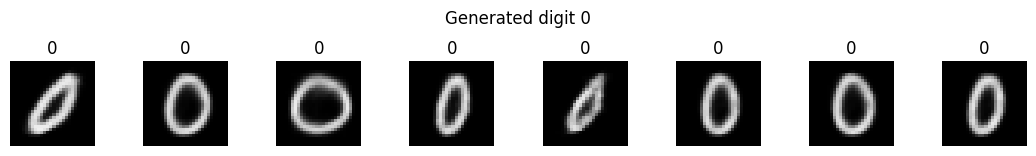

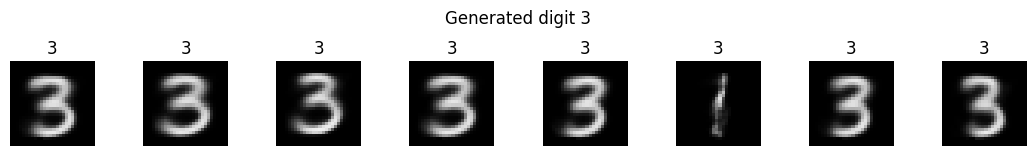

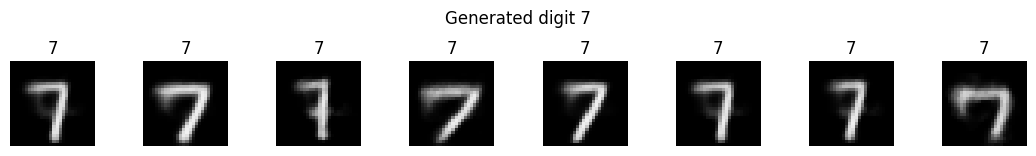

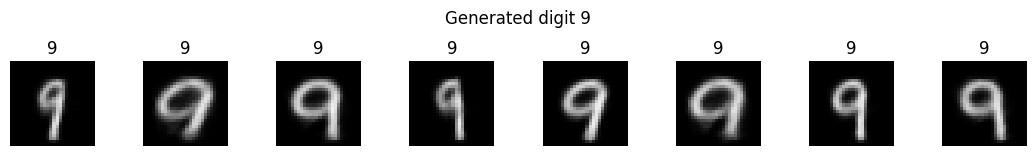

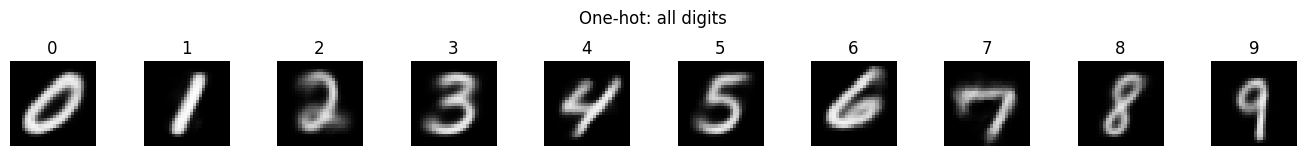

tensor([[[[-0.9997, -0.9999, -0.9999,  ..., -0.9997, -0.9997, -0.9997],
          [-0.9997, -0.9999, -0.9997,  ..., -0.9997, -0.9999, -0.9997],
          [-0.9999, -0.9997, -0.9998,  ..., -0.9998, -0.9998, -0.9995],
          ...,
          [-0.9998, -0.9998, -0.9998,  ..., -0.9998, -0.9998, -0.9998],
          [-0.9998, -0.9998, -0.9998,  ..., -0.9998, -0.9998, -0.9999],
          [-0.9998, -0.9998, -0.9998,  ..., -0.9998, -0.9999, -0.9997]]],


        [[[-0.9986, -0.9984, -0.9985,  ..., -0.9985, -0.9978, -0.9984],
          [-0.9972, -0.9984, -0.9983,  ..., -0.9984, -0.9990, -0.9981],
          [-0.9979, -0.9983, -0.9987,  ..., -0.9984, -0.9982, -0.9980],
          ...,
          [-0.9982, -0.9983, -0.9976,  ..., -0.9975, -0.9988, -0.9985],
          [-0.9983, -0.9986, -0.9984,  ..., -0.9976, -0.9978, -0.9981],
          [-0.9982, -0.9980, -0.9980,  ..., -0.9985, -0.9975, -0.9981]]],


        [[[-0.9994, -0.9995, -0.9996,  ..., -0.9997, -0.9997, -0.9994],
          [-0.9994, -0.999

In [19]:
def validate_digit(digit):
    if isinstance(digit, bool) or not isinstance(digit, int):
        raise TypeError("digit must be a Python integer.")
    if not 0 <= digit <= 9:
        raise ValueError("digit must be between 0 and 9.")


def validate_sample_count(n_samples):
    if isinstance(n_samples, bool) or not isinstance(n_samples, int):
        raise TypeError("n_samples must be an integer.")
    if n_samples < 1:
        raise ValueError("n_samples must be positive.")


def decode_images(model, z, y):
    device = next(model.parameters()).device
    previous_mode = model.training
    model.eval()

    try:
        with torch.no_grad():
            images = model.decode(
                z.to(device), y.to(device)
            ).reshape(-1, 1, 28, 28)
            return images.cpu()
    finally:
        model.train(previous_mode)


def generate_digits(model, digits, n_samples=1, title=None):
    digits = list(digits)
    if not digits:
        raise ValueError("digits cannot be empty.")

    for digit in digits:
        validate_digit(digit)
    validate_sample_count(n_samples)

    y = torch.tensor(digits, dtype=torch.long)
    y = y.repeat_interleave(n_samples)
    z = torch.randn(len(y), model.latent_dim)

    images = decode_images(model, z, y)
    labels = y

    show_images(
        images,
        labels,
        title=title or "Conditional generation",
        ncols=n_samples if n_samples > 1 else 10,
    )
    return images


def generate_digit(model, digit, n_samples=8, title=None):
    validate_digit(digit)
    return generate_digits(
        model,
        [digit],
        n_samples=n_samples,
        title=title or f"Generated digit {digit}",
    )


for digit in [0, 3, 7, 9]:
    generate_digit(onehot_model, digit)

generate_digits(onehot_model, range(10), title="One-hot: all digits")

## 10. Method 2 — Learnable Embeddings

A learned embedding maps each label to a trainable vector:

$$e_y = E[y].$$

We use a 16-dimensional embedding.

- Encoder input: `784 + 16 = 800`
- Decoder input: `2 + 16 = 18`

The embedding table is shared by the encoder and decoder.

In [8]:
class ConditionalVAEEmbedding(BaseCVAE):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(10, EMBED_DIM)

        self.encoder = nn.Sequential(
            nn.Linear(784 + EMBED_DIM, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        self.mu_head = nn.Linear(128, self.latent_dim)
        self.logvar_head = nn.Linear(128, self.latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(self.latent_dim + EMBED_DIM, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh(),
        )

    def encode(self, x, y):
        condition = self.embedding(y.long())
        h = self.encoder(
            torch.cat([x.flatten(start_dim=1), condition], dim=1)
        )
        return self.mu_head(h), self.logvar_head(h)

    def decode(self, z, y):
        condition = self.embedding(y.long())
        return self.decoder(torch.cat([z, condition], dim=1))

## 11. Train the Embedding Model

ConditionalVAEEmbedding | 01/15 | total=154.807 recon=150.580 KL=4.227
ConditionalVAEEmbedding | 02/15 | total=121.644 recon=117.158 KL=4.486
ConditionalVAEEmbedding | 03/15 | total=116.952 recon=112.346 KL=4.606
ConditionalVAEEmbedding | 04/15 | total=114.438 recon=109.768 KL=4.670
ConditionalVAEEmbedding | 05/15 | total=112.734 recon=107.984 KL=4.750
ConditionalVAEEmbedding | 06/15 | total=111.583 recon=106.783 KL=4.800
ConditionalVAEEmbedding | 07/15 | total=110.701 recon=105.861 KL=4.841
ConditionalVAEEmbedding | 08/15 | total=109.964 recon=105.093 KL=4.871
ConditionalVAEEmbedding | 09/15 | total=109.431 recon=104.534 KL=4.897
ConditionalVAEEmbedding | 10/15 | total=108.939 recon=104.009 KL=4.931
ConditionalVAEEmbedding | 11/15 | total=108.552 recon=103.607 KL=4.944
ConditionalVAEEmbedding | 12/15 | total=108.238 recon=103.258 KL=4.981
ConditionalVAEEmbedding | 13/15 | total=107.835 recon=102.822 KL=5.013
ConditionalVAEEmbedding | 14/15 | total=107.617 recon=102.605 KL=5.012
Condit

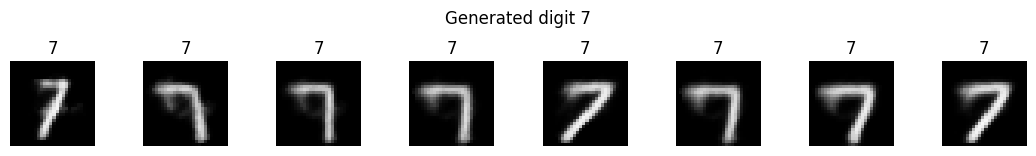

tensor([[[[-1.0000, -1.0000, -0.9999,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          ...,
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-0.9999, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -0.9999]]],


        [[[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          ...,
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000]]],


        [[[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.000

In [9]:
set_seed()
embedding_model = ConditionalVAEEmbedding().to(DEVICE)
embedding_history = train_model(embedding_model)

generate_digit(embedding_model, 7)

## 12. Compare One-Hot and Embedding

Use the same latent vectors and labels for both models. This keeps the input samples comparable, although independently trained models do not share the same latent coordinate system.

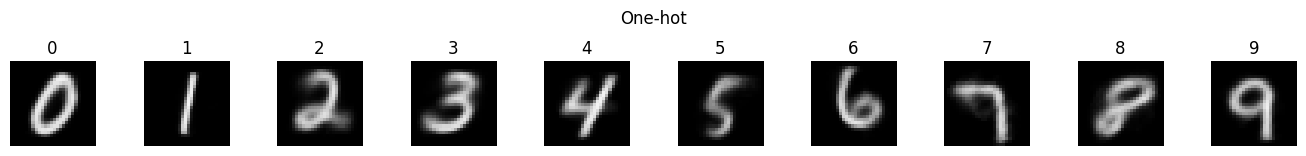

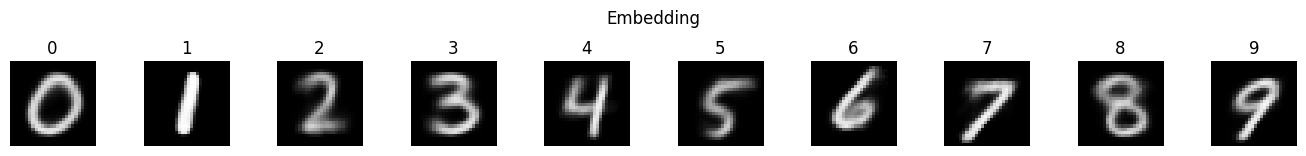

In [10]:
comparison_generator = torch.Generator().manual_seed(SEED + 1)
shared_z = torch.randn(
    10, LATENT_DIM, generator=comparison_generator
)
shared_y = torch.arange(10, dtype=torch.long)

for name, model in [
    ("One-hot", onehot_model),
    ("Embedding", embedding_model),
]:
    images = decode_images(model, shared_z, shared_y)
    show_images(images, shared_y, title=name)

## 13. Method 3 — Feature-wise Linear Modulation (FiLM)

Instead of appending the condition to the input, FiLM changes hidden features using:

$$h'=(1+\Delta\gamma(e_y))\odot h+\beta(e_y).$$

The label embedding is transformed into scale and shift parameters for an intermediate feature vector.

This is a lightweight educational FiLM implementation, not a research-grade architecture.

In [11]:
class ConditionalVAEFiLM(BaseCVAE):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(10, EMBED_DIM)

        self.encoder_input = nn.Linear(784, 256)
        self.encoder_film = nn.Linear(EMBED_DIM, 2 * 256)
        self.encoder_hidden = nn.Linear(256, 128)
        self.mu_head = nn.Linear(128, self.latent_dim)
        self.logvar_head = nn.Linear(128, self.latent_dim)

        self.decoder_input = nn.Linear(self.latent_dim, 128)
        self.decoder_film = nn.Linear(EMBED_DIM, 2 * 128)
        self.decoder_hidden = nn.Linear(128, 256)
        self.decoder_output = nn.Linear(256, 784)

        for layer in [self.encoder_film, self.decoder_film]:
            nn.init.zeros_(layer.weight)
            nn.init.zeros_(layer.bias)

    @staticmethod
    def modulate(h, parameters):
        delta_gamma, beta = parameters.chunk(2, dim=1)
        return (1 + delta_gamma) * h + beta

    def encode(self, x, y):
        condition = self.embedding(y.long())
        h = self.encoder_input(x.flatten(start_dim=1))
        h = F.relu(self.modulate(h, self.encoder_film(condition)))
        h = F.relu(self.encoder_hidden(h))
        return self.mu_head(h), self.logvar_head(h)

    def decode(self, z, y):
        condition = self.embedding(y.long())
        h = self.decoder_input(z)
        h = F.relu(self.modulate(h, self.decoder_film(condition)))
        h = F.relu(self.decoder_hidden(h))
        return torch.tanh(self.decoder_output(h))

## 14. Train the FiLM Model

In [12]:
set_seed()
film_model = ConditionalVAEFiLM().to(DEVICE)
film_history = train_model(film_model)

models = {
    "One-hot": onehot_model,
    "Embedding": embedding_model,
    "FiLM": film_model,
}

histories = {
    "One-hot": onehot_history,
    "Embedding": embedding_history,
    "FiLM": film_history,
}

ConditionalVAEFiLM | 01/15 | total=157.355 recon=153.489 KL=3.867
ConditionalVAEFiLM | 02/15 | total=117.727 recon=113.050 KL=4.677
ConditionalVAEFiLM | 03/15 | total=113.300 recon=108.500 KL=4.800
ConditionalVAEFiLM | 04/15 | total=111.294 recon=106.458 KL=4.836
ConditionalVAEFiLM | 05/15 | total=110.106 recon=105.213 KL=4.893
ConditionalVAEFiLM | 06/15 | total=109.180 recon=104.265 KL=4.915
ConditionalVAEFiLM | 07/15 | total=108.575 recon=103.622 KL=4.952
ConditionalVAEFiLM | 08/15 | total=107.977 recon=103.001 KL=4.976
ConditionalVAEFiLM | 09/15 | total=107.492 recon=102.488 KL=5.004
ConditionalVAEFiLM | 10/15 | total=107.027 recon=101.994 KL=5.034
ConditionalVAEFiLM | 11/15 | total=106.772 recon=101.733 KL=5.038
ConditionalVAEFiLM | 12/15 | total=106.469 recon=101.388 KL=5.080
ConditionalVAEFiLM | 13/15 | total=106.222 recon=101.128 KL=5.093
ConditionalVAEFiLM | 14/15 | total=105.959 recon=100.867 KL=5.092
ConditionalVAEFiLM | 15/15 | total=105.705 recon=100.606 KL=5.099


## 15. Compare All Three Models

We compare:

1. Training loss curves
2. Reconstructions of held-out images
3. Conditional prior samples
4. Posterior-mean reconstruction metrics
5. Parameter counts

The metrics here are educational diagnostics rather than a rigorous statistical benchmark.

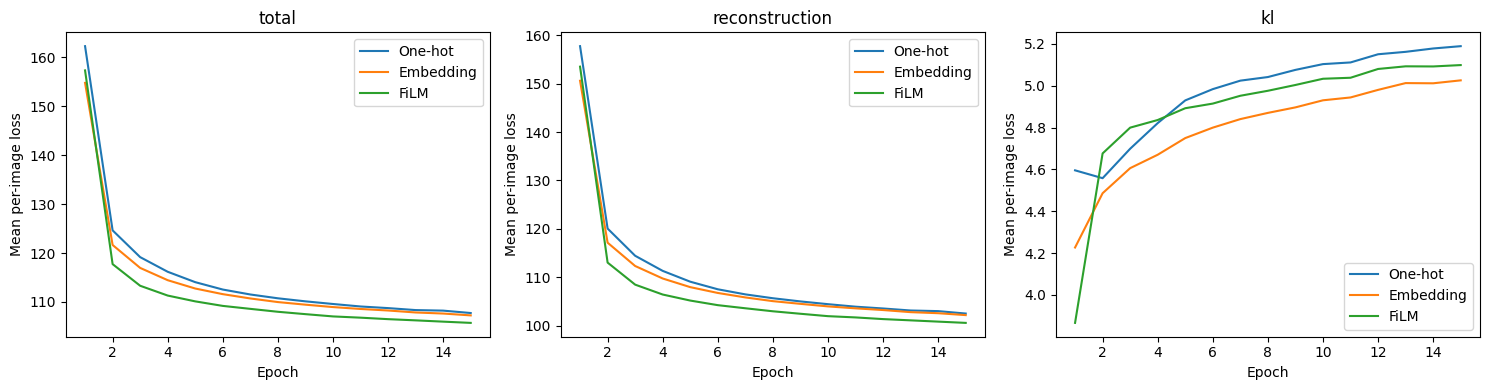

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, key in zip(axes, ["total", "reconstruction", "kl"]):
    for name, history in histories.items():
        epochs = range(1, len(history[key]) + 1)
        ax.plot(epochs, history[key], label=name)
    ax.set_title(key)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Mean per-image loss")
    ax.legend()

fig.tight_layout()
plt.show()

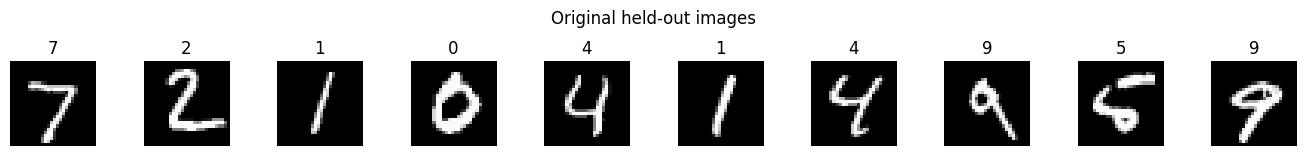

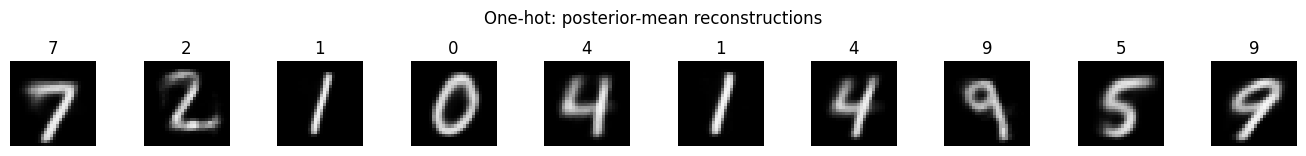

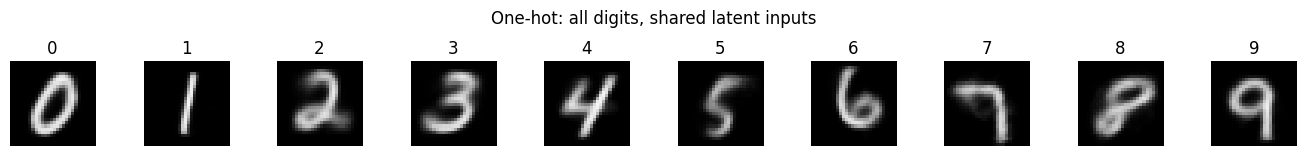

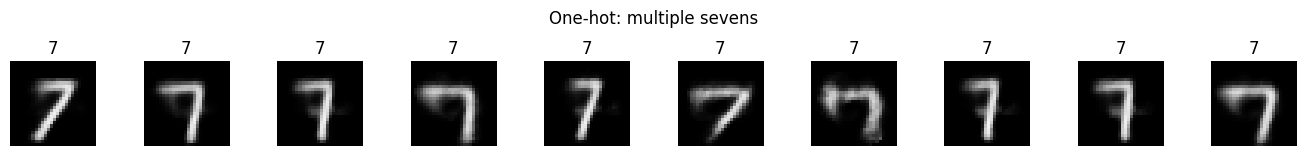

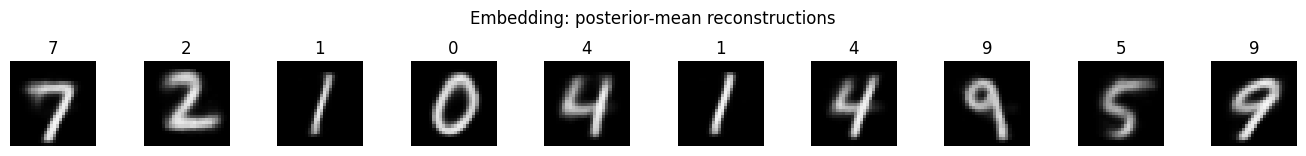

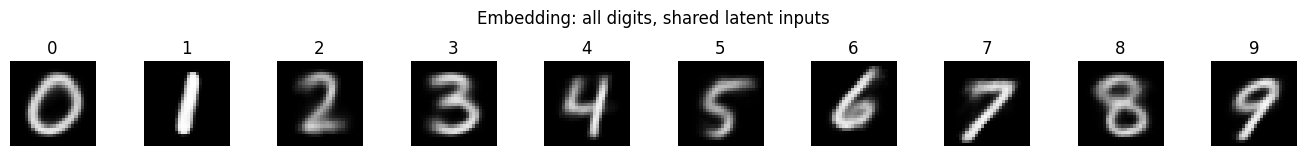

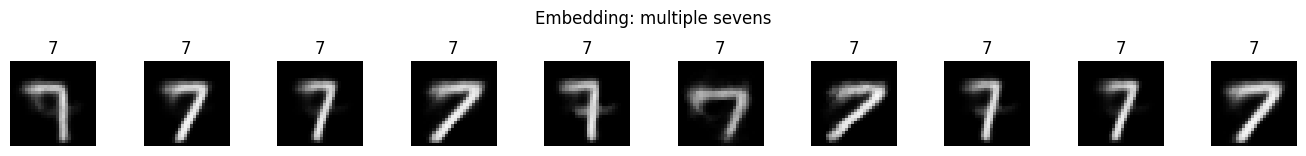

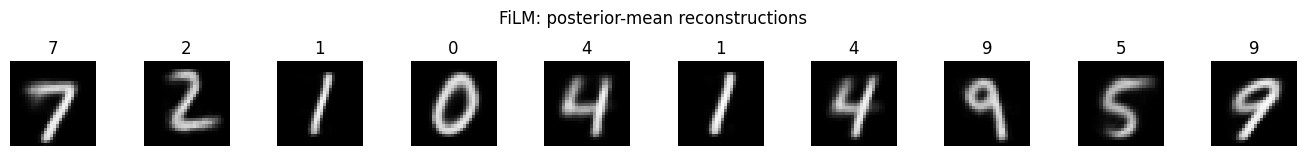

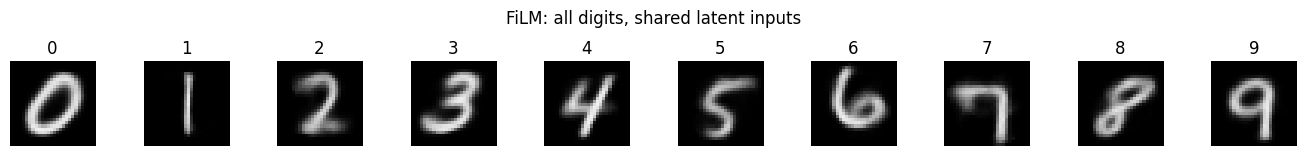

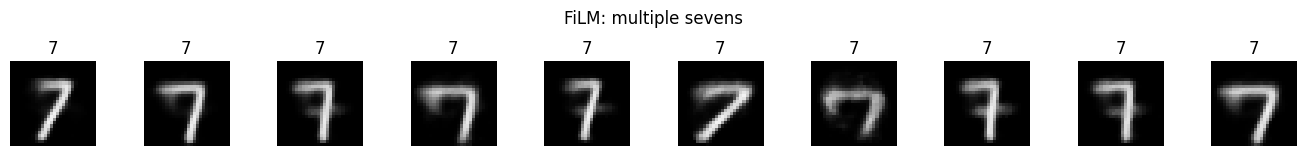

In [14]:
def posterior_reconstruction(model, x, y):
    device = next(model.parameters()).device
    previous_mode = model.training
    model.eval()

    try:
        with torch.no_grad():
            x_device = x.to(device)
            y_device = y.to(device)
            mu, _ = model.encode(x_device, y_device)
            images = model.decode(mu, y_device)
            return images.reshape(-1, 1, 28, 28).cpu()
    finally:
        model.train(previous_mode)


heldout_x = real_x[:10]
heldout_y = real_y[:10]
show_images(heldout_x, heldout_y, "Original held-out images")

seven_generator = torch.Generator().manual_seed(SEED + 10)
seven_z = torch.randn(10, LATENT_DIM, generator=seven_generator)
seven_y = torch.full((10,), 7, dtype=torch.long)

for name, model in models.items():
    reconstructions = posterior_reconstruction(
        model, heldout_x, heldout_y
    )
    show_images(
        reconstructions,
        heldout_y,
        title=f"{name}: posterior-mean reconstructions",
    )

    show_images(
        decode_images(model, shared_z, shared_y),
        shared_y,
        title=f"{name}: all digits, shared latent inputs",
    )

    show_images(
        decode_images(model, seven_z, seven_y),
        seven_y,
        title=f"{name}: multiple sevens",
    )

In [15]:
def evaluate_model(model, loader):
    device = next(model.parameters()).device
    previous_mode = model.training
    model.eval()

    totals = np.zeros(2, dtype=np.float64)
    samples = 0

    try:
        with torch.no_grad():
            for x, y in loader:
                x = x.to(device)
                y = y.to(device)

                mu, logvar = model.encode(x, y)
                reconstruction = model.decode(mu, y)
                _, reconstruction_loss, kl_loss = vae_loss(
                    reconstruction, x, mu, logvar
                )

                batch = x.size(0)
                totals += batch * np.array([
                    reconstruction_loss.item(),
                    kl_loss.item(),
                ])
                samples += batch
    finally:
        model.train(previous_mode)

    if samples == 0:
        raise ValueError("Evaluation loader is empty.")

    return {
        "reconstruction": float(totals[0] / samples),
        "kl": float(totals[1] / samples),
    }


def parameter_count(model):
    return sum(p.numel() for p in model.parameters())


metrics = {
    name: evaluate_model(model, test_loader)
    for name, model in models.items()
}

print(f"{'Model':<12} {'Params':>12} {'Train total':>13} {'Recon':>12} {'KL':>10}")
print("-" * 63)

for name, model in models.items():
    print(
        f"{name:<12} "
        f"{parameter_count(model):>12,d} "
        f"{histories[name]['total'][-1]:>13.3f} "
        f"{metrics[name]['reconstruction']:>12.3f} "
        f"{metrics[name]['kl']:>10.3f}"
    )

Model              Params   Train total        Recon         KL
---------------------------------------------------------------
One-hot           473,108       107.723      102.877      5.177
Embedding         475,572       107.237      102.492      4.886
FiLM              482,484       105.705      100.630      5.048


## 16. Condition vs. Latent Variable

Two controlled experiments:

- **Fix `z`, vary `y`:** the requested digit should change.
- **Fix `y`, vary `z`:** variation should change while the requested class remains the same.

The second experiment uses a small two-dimensional latent grid.

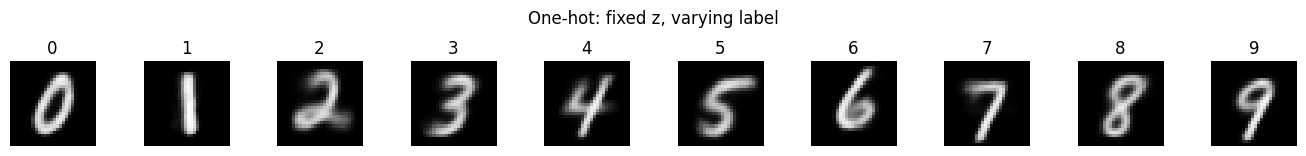

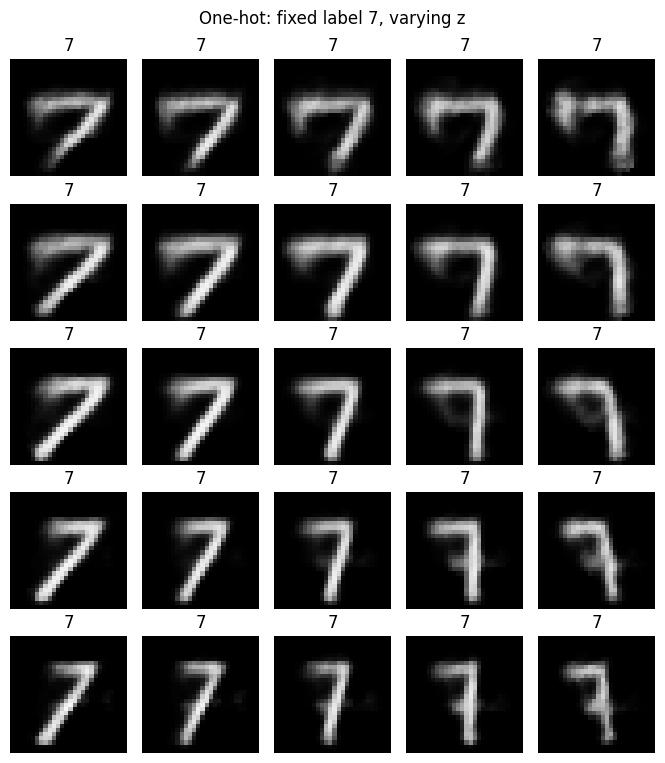

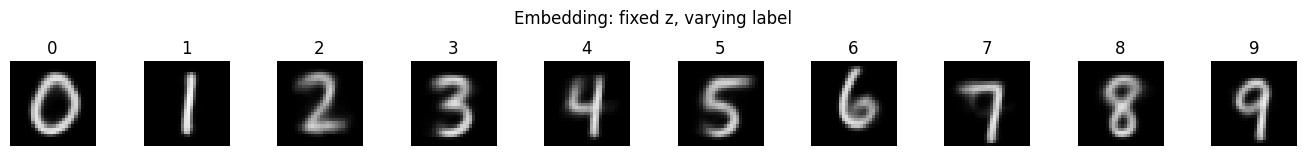

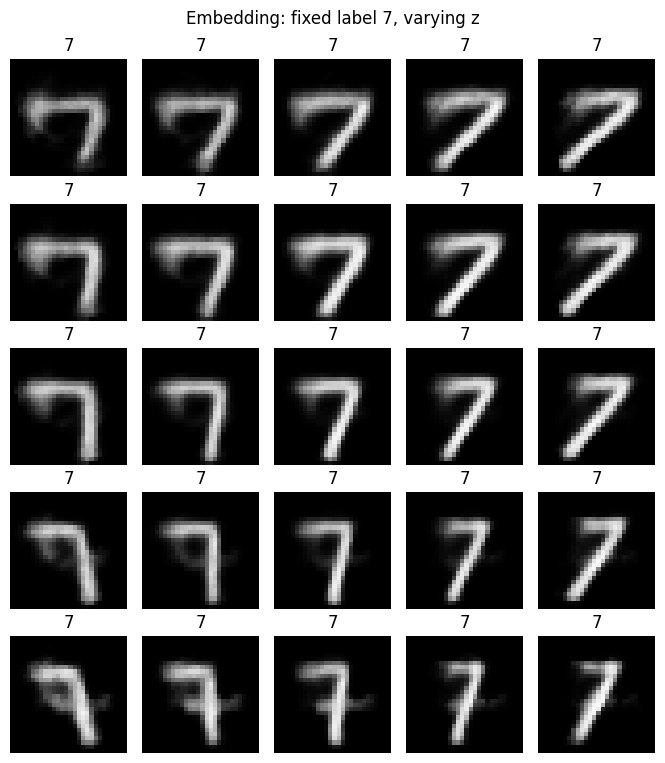

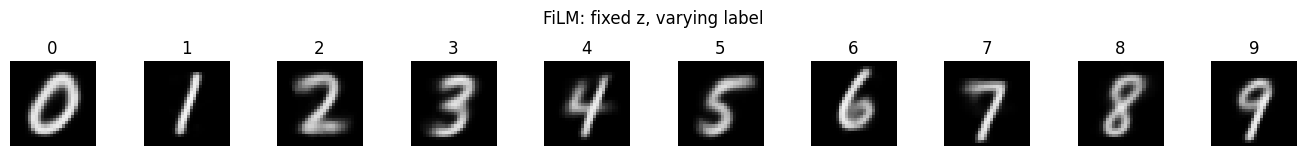

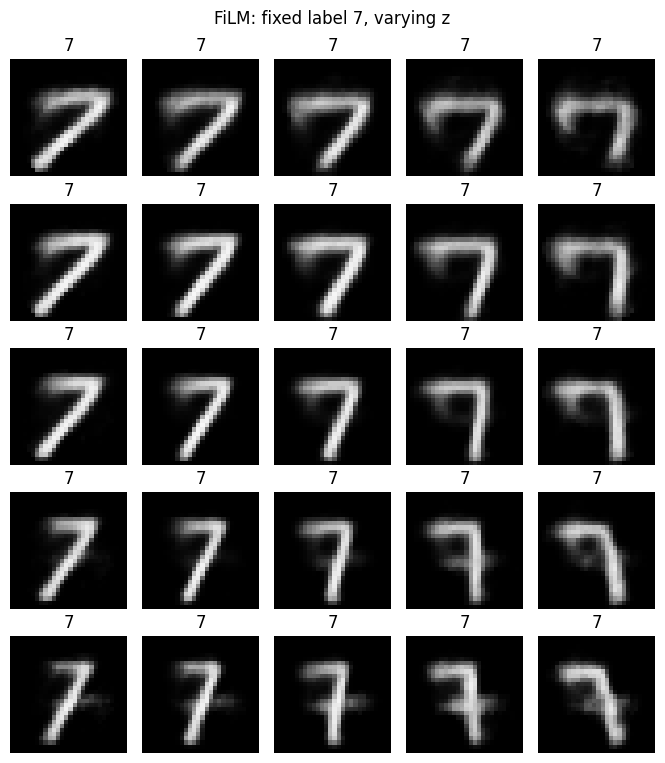

In [16]:
axis_values = torch.linspace(-2, 2, 5)
grid_z = torch.cartesian_prod(axis_values, axis_values).float()
grid_y = torch.full((len(grid_z),), 7, dtype=torch.long)

fixed_z = torch.tensor([[0.5, -0.5]]).repeat(10, 1)
varying_y = torch.arange(10, dtype=torch.long)

for name, model in models.items():
    show_images(
        decode_images(model, fixed_z, varying_y),
        varying_y,
        title=f"{name}: fixed z, varying label",
    )

    show_images(
        decode_images(model, grid_z, grid_y),
        grid_y,
        title=f"{name}: fixed label 7, varying z",
        ncols=5,
    )

## 17. Visualize the Conditional Latent Space

Plot posterior means for held-out images, colored by digit label.

A CVAE does **not** need ten perfectly separated clusters because the decoder already receives the label.

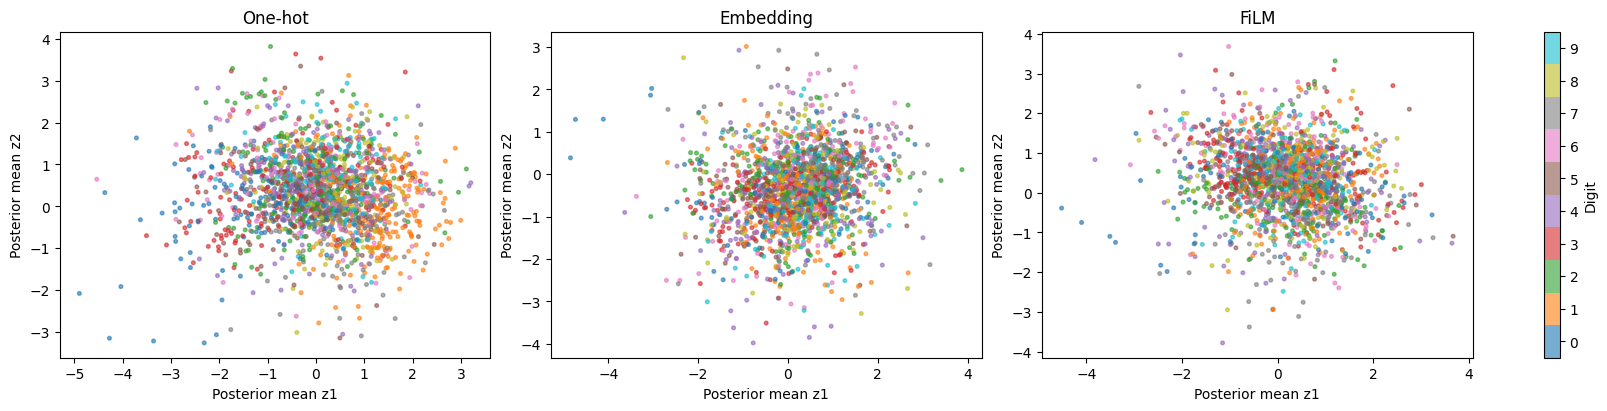

In [17]:
def collect_latents(model, loader, max_samples=2000):
    device = next(model.parameters()).device
    previous_mode = model.training
    model.eval()

    latent_batches = []
    label_batches = []
    count = 0

    try:
        with torch.no_grad():
            for x, y in loader:
                x = x.to(device)
                mu, _ = model.encode(x, y.to(device))

                latent_batches.append(mu.cpu())
                label_batches.append(y.cpu())
                count += x.size(0)

                if count >= max_samples:
                    break
    finally:
        model.train(previous_mode)

    return (
        torch.cat(latent_batches)[:max_samples].numpy(),
        torch.cat(label_batches)[:max_samples].numpy(),
    )


fig, axes = plt.subplots(
    1,
    len(models),
    figsize=(16, 4),
    constrained_layout=True,
)

for ax, (name, model) in zip(axes, models.items()):
    latent, labels = collect_latents(model, test_loader)
    scatter = ax.scatter(
        latent[:, 0],
        latent[:, 1],
        c=labels,
        cmap="tab10",
        vmin=-0.5,
        vmax=9.5,
        s=7,
        alpha=0.6,
    )
    ax.set_title(name)
    ax.set_xlabel("Posterior mean z1")
    ax.set_ylabel("Posterior mean z2")

fig.colorbar(scatter, ax=list(axes), ticks=range(10), label="Digit")
plt.show()

## 18. Final Integer API

The final interface hides the condition encoding from the user.

For example:

```python
generate_digit(film_model, 7)
```

The pipeline is:

```text
integer 7
   ↓
condition representation
   ↓
random z
   ↓
conditional decoder
   ↓
image of digit 7
```

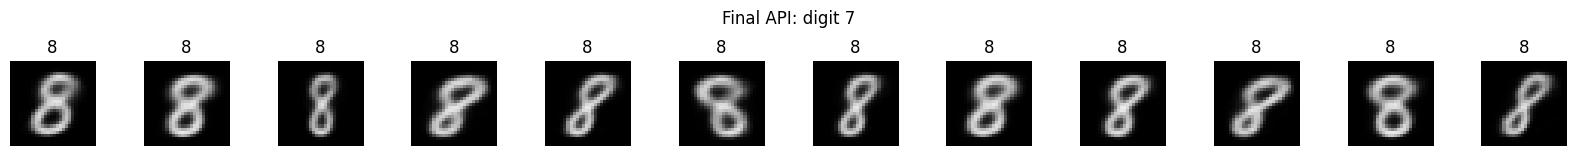

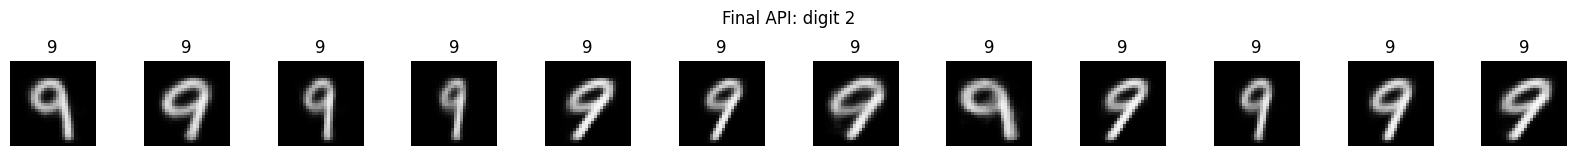

tensor([[[[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          ...,
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000]]],


        [[[-0.9998, -0.9999, -0.9999,  ..., -0.9999, -0.9999, -0.9999],
          [-0.9999, -0.9999, -0.9999,  ..., -0.9999, -0.9998, -0.9999],
          [-0.9999, -0.9999, -0.9999,  ..., -1.0000, -0.9999, -0.9999],
          ...,
          [-0.9999, -0.9998, -0.9999,  ..., -0.9999, -0.9999, -0.9999],
          [-0.9999, -0.9998, -0.9999,  ..., -0.9998, -0.9999, -0.9998],
          [-0.9999, -0.9999, -0.9999,  ..., -0.9999, -0.9999, -0.9999]]],


        [[[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.000

In [24]:
# Try any digit from 0 to 9.
generate_digit(film_model, 8, n_samples=12, title="Final API: digit 7")
generate_digit(film_model, 9, n_samples=12, title="Final API: digit 2")

## 19. Common Mistakes

### 1. Treating `7` as an ordinary continuous scalar
A categorical label is not naturally an ordinal feature. One-hot encoding or a learned embedding is usually a better representation.

### 2. Conditioning only the encoder
Generation happens through the decoder, so the decoder needs the requested condition too.

### 3. Sending a real image during generation
A CVAE can generate directly from `z + y`. No real input image is required.

### 4. Mismatching normalization and decoder activation
Here we use `[-1, 1]` inputs with a final `Tanh` output.

### 5. Concatenating along the wrong dimension
For `[B, features]` tensors, concatenate conditions with `dim=1`.

## 20. Final Comparison

| Model | Condition representation | Main idea | Complexity |
|---|---|---|---|
| VAE | None | Random generation | Low |
| CVAE + One-hot | Fixed 10D vector | Concatenate condition | Very low |
| CVAE + Embedding | Learned 16D vector | Learned categorical representation | Low |
| CVAE + FiLM | Learned embedding | Modulate hidden features | Medium |

The important conceptual change is:

```text
VAE:
random z → generated sample

CVAE:
random z + requested label → controlled sample
```

## 21. Key Takeaways

1. A CVAE adds a condition to both the encoder and decoder.
2. One-hot concatenation is the simplest conditioning strategy.
3. Embeddings learn a vector representation for categorical labels.
4. FiLM injects the condition into intermediate features.
5. The condition mainly controls **what** is generated, while `z` provides **variation**.
6. A real integer such as `7` can be converted internally and used to generate a digit-7 image.